The contents of this notebook were created with assistance from Claude generative AI.

# Stance feature-importance & ablation toolkit

Group-aware ablation + token-level attribution for the **tuned XGBoost** stance model (bge embeddings ⊕ sentiment ⊕ metadata) and the **tuned ModernBERT** classifier — the best 5-fold-CV configs from *Project Data - 15 — Tuned 5fold CV* — evaluated on the 301-item human gold set with bootstrap uncertainty throughout.

Data, features, and models are loaded through that project's `m5_common` module, so this notebook always matches the deployed pipeline. Run the cells top to bottom (the **Config** and **Loaders** cells are already wired up).

**Run it with the `mads-m2-eval` kernel** (has shap + captum on top of the classifier stack).

### What each piece answers
- **"Which model is best, and is the win real?"** — `paired_bootstrap_f1_diff`: paired, stratified bootstrap CI on the macro-F1 *difference* on the same gold items (4-class and 3-class on-topic). CI excludes 0 ⇒ significant.
- **"Where do the errors go?"** — `normalized_confusion`: row-normalized (diagonal = per-class recall); exposes neutral/off-topic → polar leakage.
- **"Which features, when removed, most hurt performance?"** — `leave_one_group_out`: retrains XGBoost without each group, ΔF1 with paired-bootstrap CI (necessity).
- **"What does the fitted model lean on?"** — `grouped_permutation_importance` (deployed-model reliance) and `grouped_treeshap` (attribution, with mean-|SHAP|-per-column so the 768-dim embedding block can't dominate purely on column count).
- **Actual words** — `xgb_top_tokens` (SHAP Partition over the re-embedding pipeline) and `modernbert_top_tokens` (Captum LayerIntegratedGradients).

> **Necessity vs. attribution.** Leave-one-out / permutation measure *unique conditional* contribution; a feature redundant with another (likely between the embedding block and sentiment) looks unimportant to them while still carrying high SHAP. Agreement ⇒ strong claim; disagreement ⇒ redundancy.

> **Weighting.** The head-to-head macro-F1, per-class F1, confusion matrices, and the leave-one-group-out / permutation ΔF1 are all **population-weighted** with the gold weights `w` (`n_cell / #sampled-in-cell`), so the reported numbers match the population-weighted gold headline in Project Data - 15 (up to bootstrap noise). SHAP attribution is left unweighted — it characterizes the model, not the eval sample. Note LOGO retraining still uses the tuned XGB hyperparameters *without* class weighting, so its full-model F1 is a retrain baseline, not the deployed number; read the ΔF1 columns, which are internally consistent.

## Setup

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = "1"

## 1. Config

Labels, feature groups, and the tuned XGBoost hyperparameters, all derived from `m5_common` so they track the saved models. The 152 sentiment column names come straight from the sentiment snapshot; metadata is `is_post` + `log1p(len)`.

In [3]:
# Wire the toolkit to the Project Data - 15 tuned classifiers via their shared
# m5_common module (the single source of truth for data prep + features).
import sys
from pathlib import Path

P15 = Path.cwd()
if str(P15) not in sys.path:
    sys.path.insert(0, str(P15))
import m5_common as m5

# ---- labels (4-class stance; "off-topic" is the off-axis NA class) ----------
CLASS_ORDER     = list(m5.LABELS)        # ["anti", "neutral", "pro", "off-topic"]
ONTOPIC_CLASSES = list(m5.ON_TOPIC)      # ["anti", "neutral", "pro"]
NA_LABEL        = "off-topic"

# ---- XGBoost feature space (bge embedding ⊕ metadata ⊕ sentiment) -----------
# m5.xgb_feats() hstacks: embed(text)[768] ⊕ meta[2] ⊕ sentiment[152]. We name
# those columns so the grouped/ablation analyses can address them by group.
EMBEDDING_PREFIX = "emb_"                            # emb_0 .. emb_767
METADATA_COLS    = ["meta_is_post", "meta_loglen"]   # m5.meta(): is_post, log1p(len(target))
SENTIMENT_COLS   = list(m5._sent_feats().columns)    # 152 numeric sentiment features
GROUP_NAMES      = ["embeddings", "sentiment", "metadata"]

def scalar_cols():
    return list(SENTIMENT_COLS) + list(METADATA_COLS)

# ---- XGBoost hyperparameters = the tuned best-5-fold-CV config ---------------
# Read straight from the tuned store so this stays in sync with the saved model.
# Used when RE-training for leave-one-group-out necessity ablation.
_hp = m5.read_tuned_hp().get("XGBoost", {})
XGB_PARAMS = {k: v for k, v in dict(
    n_estimators     = _hp.get("n_estimators", 1000),
    max_depth        = _hp.get("max_depth"),
    learning_rate    = _hp.get("learning_rate"),
    min_child_weight = _hp.get("min_child_weight"),
    subsample        = _hp.get("subsample"),
    colsample_bytree = _hp.get("colsample_bytree"),
    gamma            = _hp.get("gamma"),
    reg_lambda       = _hp.get("reg_lambda"),
    objective        = "multi:softprob",
    tree_method      = "hist",
    device           = "cuda",
    eval_metric      = "mlogloss",
    random_state     = m5.SEED,
).items() if v is not None}

# ---- bootstrap / run control ------------------------------------------------
N_BOOTSTRAP     = 5000
SEED            = m5.SEED          # 42
TOKENS_PER_CLASS = 60             # gold items explained per class for top-token passes
TOP_K_TOKENS     = 20
OUTPUT_DIR       = "outputs"

print("classes:", CLASS_ORDER)
print(f"feature groups: embeddings(emb_*) + metadata({len(METADATA_COLS)}) + sentiment({len(SENTIMENT_COLS)})")
print("XGB_PARAMS:", XGB_PARAMS)

classes: ['anti', 'neutral', 'pro', 'off-topic']
feature groups: embeddings(emb_*) + metadata(2) + sentiment(152)
XGB_PARAMS: {'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.037089282452166986, 'min_child_weight': 8, 'subsample': 0.7783033443358875, 'colsample_bytree': 0.8678898606887231, 'gamma': 0.41250024848577704, 'reg_lambda': 3.876094171803447, 'objective': 'multi:softprob', 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'mlogloss', 'random_state': 42}


## 2. Loaders

Thin wrappers over `m5_common`: the tuned XGBoost is wrapped so the toolkit sees string labels and named feature columns; the pool feature matrix is read from the on-disk cache (no re-embedding of 4,830 rows); the gold set is embedded on GPU. ModernBERT loads onto CUDA.

In [4]:
# Loaders wired to the Project Data - 15 tuned models. The best 5-fold-CV configs
# are the *tuned* XGBoost (CV macro-F1 .506) and *tuned* ModernBERT (CV .566).
import numpy as np
import pandas as pd


def _named_feature_df(X):
    """Wrap an m5.xgb_feats hstack (embed ⊕ meta ⊕ sentiment) as a named frame."""
    X = np.asarray(X)
    n_scalar = len(METADATA_COLS) + len(SENTIMENT_COLS)
    d = X.shape[1] - n_scalar
    cols = [f"{EMBEDDING_PREFIX}{i}" for i in range(d)] + list(METADATA_COLS) + list(SENTIMENT_COLS)
    return pd.DataFrame(X, columns=cols)


class _LoadedXGB:
    """Adapter around the saved tuned XGBClassifier so the toolkit sees a sklearn-
    like surface: string .predict / .predict_proba (columns in CLASS_ORDER),
    .classes_, .feature_names_in_, and ._model (SHAP unwraps getattr(m,'model',m))."""
    def __init__(self, clf, feature_names):
        self.model = clf
        self.feature_names_in_ = np.asarray(feature_names, dtype=object)
        self.classes_ = np.asarray(CLASS_ORDER, dtype=object)

    @staticmethod
    def _arr(X):
        return X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)

    def predict(self, X):
        idx = self.model.predict(self._arr(X)).astype(int)
        return np.asarray([CLASS_ORDER[i] for i in idx], dtype=object)

    def predict_proba(self, X):
        return self.model.predict_proba(self._arr(X))


def load_xgb_model():
    import xgboost as xgb
    clf = xgb.XGBClassifier()
    clf.load_model(str(m5.model_path("tuned", "XGBoost")))
    clf.get_booster().set_param({"device": "cuda"})
    d = clf.get_booster().num_features() - len(METADATA_COLS) - len(SENTIMENT_COLS)   # 768
    cols = [f"{EMBEDDING_PREFIX}{i}" for i in range(d)] + list(METADATA_COLS) + list(SENTIMENT_COLS)
    return _LoadedXGB(clf, cols)


def load_xgb_frames():
    """(train_df, y_train, gold_df, y_gold) as named frames + string labels.
    train_df is the gold-removed weak-labeled pool (reused for LOGO retraining);
    gold_df is the 301-item human gold set."""
    fr = m5.load_frames()
    pool = fr["df"].reset_index(drop=True)
    gold = fr["gold_text"].reset_index(drop=True)
    X_train, y_idx = m5.get_xgb_cache(pool)              # disk-cached: no re-embed of the 4,830-row pool
    train_df = _named_feature_df(X_train)
    y_train = pd.Series(y_idx).map(m5.i2lab).to_numpy(dtype=object)
    gold_df = _named_feature_df(m5.xgb_feats(gold))      # 301 rows, embedded on GPU
    y_gold = gold["label"].to_numpy(dtype=object)
    return train_df, y_train, gold_df, y_gold


def load_gold_texts():
    """Raw [CONTEXT]/[TARGET] text per gold item, aligned to gold_df's row order."""
    gold = m5.load_frames()["gold_text"].reset_index(drop=True)
    return gold["text"]


def embed_fn(texts):
    """Same bge-base-en-v1.5 encoder that produced the XGBoost embedding columns."""
    return m5.embed(list(texts))


def load_modernbert():
    """Tuned ModernBERT (best CV) + tokenizer, on GPU in eval mode."""
    import json
    import torch  # noqa: F401
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    p = m5.model_path("tuned", "ModernBERT")
    cfg = json.loads((p / "inference_config.json").read_text())
    tok = AutoTokenizer.from_pretrained(p)
    tok.truncation_side = cfg.get("truncation_side", "left")
    model = AutoModelForSequenceClassification.from_pretrained(p).to("cuda").eval()
    return model, tok


def load_modernbert_gold_texts_and_labels():
    gold = m5.load_frames()["gold_text"].reset_index(drop=True)
    return gold["text"].tolist(), gold["label"].tolist()


def load_gold_weights():
    """Gold population weights (w = n_cell / #items-sampled-in-cell), aligned to
    gold_df's row order. Passing these reproduces the population-weighted gold
    headline in Project Data - 15; omit them for an unweighted item-level read."""
    gold = m5.load_frames()["gold_text"].reset_index(drop=True)
    return gold["w"].to_numpy(dtype=float)


## 3. Metrics — macro-F1 with paired stratified bootstrap

In [5]:
"""
Evaluation metrics with uncertainty.

The core object is a PAIRED, STRATIFIED bootstrap over gold items. Paired = both
models (or full vs ablated) are scored on the SAME resampled items each iteration
and the difference is taken inside the loop, which respects the fact that the
models err on the same hard items. Stratified = we resample within each true class
so a replicate can't accidentally contain zero of a rare class.

Every scorer accepts an optional `sample_weight`. Pass the gold population weights
(w = n_cell / #sampled-in-cell) to reproduce the population-weighted headline from
Project Data - 15; omit them for an unweighted, item-level read.
"""
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix


def _as_arr(x):
    return np.asarray(x, dtype=object)


def macro_f1(y_true, y_pred, labels, restrict_true_to=None, sample_weight=None):
    """Macro-F1 over `labels`. If restrict_true_to is given, only items whose TRUE
    label is in that set are scored (the 3-class on-topic number). A prediction
    outside `labels` counts as a non-match. `sample_weight` is filtered alongside."""
    y_true, y_pred = _as_arr(y_true), _as_arr(y_pred)
    sw = None if sample_weight is None else np.asarray(sample_weight, dtype=float)
    if restrict_true_to is not None:
        m = np.isin(y_true, list(restrict_true_to))
        y_true, y_pred = y_true[m], y_pred[m]
        if sw is not None:
            sw = sw[m]
    return f1_score(y_true, y_pred, labels=list(labels),
                    average="macro", sample_weight=sw, zero_division=0)


def per_class_f1(y_true, y_pred, labels, restrict_true_to=None, sample_weight=None):
    y_true, y_pred = _as_arr(y_true), _as_arr(y_pred)
    sw = None if sample_weight is None else np.asarray(sample_weight, dtype=float)
    if restrict_true_to is not None:
        m = np.isin(y_true, list(restrict_true_to))
        y_true, y_pred = y_true[m], y_pred[m]
        if sw is not None:
            sw = sw[m]
    f = f1_score(y_true, y_pred, labels=list(labels),
                 average=None, sample_weight=sw, zero_division=0)
    return dict(zip(labels, f))


def _stratified_indices(y_true, rng):
    """Resample WITH replacement within each true class; concatenate."""
    y_true = _as_arr(y_true)
    idx = np.arange(len(y_true))
    parts = []
    for c in np.unique(y_true):
        ci = idx[y_true == c]
        parts.append(rng.choice(ci, size=len(ci), replace=True))
    return np.concatenate(parts)


def single_bootstrap_f1(y_true, y_pred, labels, restrict_true_to=None,
                        B=5000, seed=0, sample_weight=None):
    """95% bootstrap CI for one model's macro-F1."""
    y_true, y_pred = _as_arr(y_true), _as_arr(y_pred)
    sw = None if sample_weight is None else np.asarray(sample_weight, dtype=float)
    rng = np.random.default_rng(seed)
    point = macro_f1(y_true, y_pred, labels, restrict_true_to, sw)
    boot = np.empty(B)
    for b in range(B):
        ix = _stratified_indices(y_true, rng)
        boot[b] = macro_f1(y_true[ix], y_pred[ix], labels, restrict_true_to,
                           None if sw is None else sw[ix])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return dict(point=point, ci=(lo, hi), dist=boot)


def paired_bootstrap_f1_diff(y_true, pred_a, pred_b, labels,
                             restrict_true_to=None, B=5000, seed=0,
                             name_a="A", name_b="B", sample_weight=None):
    """Paired stratified bootstrap CI for (F1_a - F1_b) on the same gold items.
    `sample_weight` (e.g. gold population weights) is carried through the resample.
    CI excludes 0 ⇒ 'significant' at ~0.05; straddles 0 ⇒ no claimable winner."""
    y_true = _as_arr(y_true)
    pred_a, pred_b = _as_arr(pred_a), _as_arr(pred_b)
    sw = None if sample_weight is None else np.asarray(sample_weight, dtype=float)
    rng = np.random.default_rng(seed)

    f1a = macro_f1(y_true, pred_a, labels, restrict_true_to, sw)
    f1b = macro_f1(y_true, pred_b, labels, restrict_true_to, sw)
    diffs = np.empty(B)
    for b in range(B):
        ix = _stratified_indices(y_true, rng)
        swi = None if sw is None else sw[ix]
        da = macro_f1(y_true[ix], pred_a[ix], labels, restrict_true_to, swi)
        db = macro_f1(y_true[ix], pred_b[ix], labels, restrict_true_to, swi)
        diffs[b] = da - db
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    # two-sided bootstrap p-value for H0: diff == 0.
    p = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    p = min(1.0, p)
    return dict(
        name_a=name_a, name_b=name_b,
        f1_a=f1a, f1_b=f1b, diff=f1a - f1b,
        ci=(lo, hi), p_value=p, dist=diffs,
        significant=(lo > 0 or hi < 0),
    )


def normalized_confusion(y_true, y_pred, labels, sample_weight=None):
    """Row-normalized (by true class) confusion matrix. Diagonal = per-class
    recall (weighted if sample_weight given); off-diagonals show error leakage.
    Returns (matrix, labels)."""
    sw = None if sample_weight is None else np.asarray(sample_weight, dtype=float)
    cm = confusion_matrix(_as_arr(y_true), _as_arr(y_pred),
                          labels=list(labels), normalize="true", sample_weight=sw)
    return cm, list(labels)

## 4. Ablation & feature importance (XGBoost)

`StringLabelXGB` retrains in string-label space for leave-one-group-out. Three complementary views: LOGO (necessity), grouped permutation (deployed-model reliance), TreeSHAP (attribution).

In [6]:
"""
XGBoost feature analysis, group-aware.

Three complementary views, on purpose:
  - leave_one_group_out : NECESSITY. Retrain without a group, measure drop in
        gold macro-F1 (with a paired bootstrap CI on the drop). This is the
        direct answer to "which features, when removed, most hurt performance".
  - grouped_permutation : reliance of the DEPLOYED model, no retraining.
  - grouped_treeshap / scalar_treeshap : ATTRIBUTION (how much the fitted model
        leans on each group / each scalar column).

Necessity and attribution diverge under redundancy (very likely between your
embedding block and sentiment columns): a redundant group looks unimportant to
LOGO/permutation because the others cover for it, yet can carry high SHAP. Show
all three; agreement = strong claim, disagreement = redundancy.

Work in GROUPS, never raw embedding dims. Individual scalar columns also get
their own leave-one-out so you can rank named sentiment/metadata features.
"""
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



class StringLabelXGB:
    """Thin wrapper so the whole codebase works in STRING-label space while
    XGBoost trains on encoded ints (recent XGBoost rejects raw string labels).
    Exposes the sklearn surface the rest of the code relies on: .predict
    (returns strings), .predict_proba (columns aligned to .classes_), .classes_
    (strings), .feature_names_in_.

    If your already-trained model returns string labels, you don't need this.
    If it returns ints, wrap/adapt it to expose the same surface.
    """
    def __init__(self, **params):
        self.params = params
        self.le = LabelEncoder()
        self.model = XGBClassifier(**params)

    def fit(self, X, y):
        y_enc = self.le.fit_transform(np.asarray(y, dtype=object))
        self.model.fit(X, y_enc)
        self.classes_ = self.le.classes_
        self.feature_names_in_ = np.asarray(X.columns)
        return self

    def predict(self, X):
        return self.le.inverse_transform(self.model.predict(X))

    def predict_proba(self, X):
        # reorder proba columns to match self.classes_ (already aligned, since
        # XGB classes are 0..k-1 == LabelEncoder order)
        return self.model.predict_proba(X)


# ---------------------------------------------------------------------------
# group resolution
# ---------------------------------------------------------------------------
def embedding_cols(df):
    return [c for c in df.columns if str(c).startswith(EMBEDDING_PREFIX)]


def feature_groups(df):
    """name -> list of column names, resolved against an actual frame."""
    return {
        "embeddings": embedding_cols(df),
        "sentiment": [c for c in SENTIMENT_COLS if c in df.columns],
        "metadata": [c for c in METADATA_COLS if c in df.columns],
    }


def _fit(train_df, y_train, cols, params):
    model = StringLabelXGB(**params)
    model.fit(train_df[cols], y_train)
    return model


# ---------------------------------------------------------------------------
# 1. leave-one-group-out (and leave-one-scalar-out)  -- NECESSITY
# ---------------------------------------------------------------------------
def leave_one_group_out(train_df, y_train, gold_df, y_gold, labels,
                        restrict_true_to=None, params=None,
                        also_individual_scalars=True, B=2000, seed=0,
                        sample_weight=None):
    """Retrain with each group (and optionally each scalar column) removed.

    Returns a DataFrame, one row per ablated unit, with the full-model F1, the
    ablated F1, delta_f1 = full - ablated (bigger = more necessary), the 95%
    paired-bootstrap CI on that delta, and a significance flag. Sorted by delta.
    """
    params = params or XGB_PARAMS
    gold_df = gold_df[train_df.columns]                 # enforce column order
    groups = feature_groups(train_df)
    all_cols = list(train_df.columns)

    full_model = _fit(train_df, y_train, all_cols, params)
    full_pred = full_model.predict(gold_df)
    full_f1 = macro_f1(y_gold, full_pred, labels, restrict_true_to, sample_weight)

    units = {f"group:{g}": cols for g, cols in groups.items() if cols}
    if also_individual_scalars:
        for c in scalar_cols():
            if c in train_df.columns:
                units[f"col:{c}"] = [c]

    rows = []
    for name, drop_cols in units.items():
        keep = [c for c in all_cols if c not in set(drop_cols)]
        if not keep:
            continue
        m = _fit(train_df, y_train, keep, params)
        abl_pred = m.predict(gold_df[keep])
        res = paired_bootstrap_f1_diff(
            y_gold, full_pred, abl_pred, labels, restrict_true_to,
            B=B, seed=seed, name_a="full", name_b=name, sample_weight=sample_weight)
        rows.append(dict(
            unit=name, n_cols=len(drop_cols),
            full_f1=res["f1_a"], ablated_f1=res["f1_b"],
            delta_f1=res["diff"], ci_low=res["ci"][0], ci_high=res["ci"][1],
            p_value=res["p_value"], significant=res["significant"],
        ))
    out = pd.DataFrame(rows).sort_values("delta_f1", ascending=False)
    out.attrs["full_f1"] = full_f1
    return out.reset_index(drop=True)


# ---------------------------------------------------------------------------
# 2. grouped permutation importance  -- deployed-model reliance
# ---------------------------------------------------------------------------
def grouped_permutation_importance(model, gold_df, y_gold, labels,
                                   restrict_true_to=None, n_repeats=20, seed=0,
                                   sample_weight=None):
    """Jointly permute the ROWS of each group's columns (preserving intra-group
    correlation, breaking the group->label relation) and measure the drop in
    gold macro-F1 of the already-fitted model. Returns mean & std drop per group.
    """
    rng = np.random.default_rng(seed)
    gold_df = gold_df[model.feature_names_in_] if hasattr(
        model, "feature_names_in_") else gold_df
    base = macro_f1(y_gold, model.predict(gold_df), labels, restrict_true_to, sample_weight)
    groups = feature_groups(gold_df)

    rows = []
    for g, cols in groups.items():
        if not cols:
            continue
        drops = []
        for _ in range(n_repeats):
            perm = gold_df.copy()
            order = rng.permutation(len(perm))
            perm[cols] = perm[cols].to_numpy()[order]   # joint row shuffle
            f1 = macro_f1(y_gold, model.predict(perm), labels, restrict_true_to, sample_weight)
            drops.append(base - f1)
        rows.append(dict(group=g, n_cols=len(cols),
                         importance=float(np.mean(drops)),
                         std=float(np.std(drops))))
    return (pd.DataFrame(rows).sort_values("importance", ascending=False)
            .reset_index(drop=True))


# ---------------------------------------------------------------------------
# 3. TreeSHAP  -- ATTRIBUTION
# ---------------------------------------------------------------------------
def _shap_values(model, df):
    """Return SHAP array shaped (n_samples, n_features, n_classes), robust to
    shap version differences for multiclass tree models."""
    import shap
    booster = getattr(model, "model", model)       # unwrap StringLabelXGB
    expl = shap.TreeExplainer(booster)
    sv = expl.shap_values(df)
    if isinstance(sv, list):                       # list[n_classes] of (n, p)
        sv = np.stack(sv, axis=-1)                 # -> (n, p, n_classes)
    elif sv.ndim == 2:                             # binary / single output
        sv = sv[:, :, None]
    return sv                                       # (n, p, k)


def grouped_treeshap(model, gold_df):
    """Per-group importance = mean over samples of summed |SHAP| across the
    group's columns, then summed over classes. Also reports mean |SHAP| PER
    COLUMN so 'embeddings dominate' can't be a mere artifact of having 768
    columns to accumulate. Returns a DataFrame.
    """
    gold_df = gold_df[model.feature_names_in_] if hasattr(
        model, "feature_names_in_") else gold_df
    sv = _shap_values(model, gold_df)               # (n, p, k)
    abs_mean = np.abs(sv).mean(axis=0)              # (p, k)
    per_col = abs_mean.sum(axis=1)                  # (p,)  sum over classes
    cols = list(gold_df.columns)
    col_imp = dict(zip(cols, per_col))
    groups = feature_groups(gold_df)

    rows = []
    for g, gcols in groups.items():
        if not gcols:
            continue
        vals = np.array([col_imp[c] for c in gcols])
        rows.append(dict(group=g, n_cols=len(gcols),
                         sum_abs_shap=float(vals.sum()),
                         mean_abs_shap_per_col=float(vals.mean())))
    grouped = (pd.DataFrame(rows).sort_values("sum_abs_shap", ascending=False)
               .reset_index(drop=True))
    return grouped, col_imp


def scalar_treeshap(model, gold_df, class_index=None):
    """SHAP values + feature values for the INTERPRETABLE scalar columns only
    (the beeswarm inputs). Embeddings are excluded — they have no per-dim
    meaning. If class_index is None, returns a dict per class.
    """
    gold_df = gold_df[model.feature_names_in_] if hasattr(
        model, "feature_names_in_") else gold_df
    scal = [c for c in scalar_cols() if c in gold_df.columns]
    sv = _shap_values(model, gold_df)               # (n, p, k)
    idx = [list(gold_df.columns).index(c) for c in scal]
    sv_scalar = sv[:, idx, :]                        # (n, n_scalar, k)
    feat_vals = gold_df[scal].to_numpy(dtype=float)

    classes = list(model.classes_)
    if class_index is not None:
        return dict(cols=scal, shap=sv_scalar[:, :, class_index],
                    feat_vals=feat_vals, class_name=classes[class_index])
    return {classes[k]: dict(cols=scal, shap=sv_scalar[:, :, k],
                             feat_vals=feat_vals, class_name=classes[k])
            for k in range(sv_scalar.shape[2])}

## 5. Token-level attribution (actual words)

XGBoost via SHAP's Partition explainer over the re-embedding pipeline (sentiment and metadata held fixed while text is masked); ModernBERT via Captum LayerIntegratedGradients on the embedding layer.

In [7]:
"""
Token-level (actual words) attribution for BOTH models, so you get a
comparable view even though their tabular feature spaces are totally different.

XGBoost: the model never saw words, only a dense embedding + scalar columns.
To get words out, we explain the WHOLE downstream pipeline as a function of raw
text:  f(text) = xgb.predict_proba( [embed(text)  ||  this item's fixed scalars] )
and hand f to SHAP's Partition explainer, which masks spans of text, re-embeds,
re-predicts, and attributes the change back to tokens. Caveats, stated plainly:
  * sentiment/metadata are held FIXED while masking text, so this attributes
    only the embedding-derived (text) signal to words. Explain the scalars
    separately with scalar_treeshap(). (Recomputing sentiment from masked text
    each time would be more faithful but rarely worth the cost.)
  * sentence embeddings are not compositional, so masking one word perturbs the
    whole vector — these are INDICATIVE top tokens, not exact Shapley values.

ModernBERT: a genuine text classifier, so we use Integrated Gradients (Captum
LayerIntegratedGradients on the embedding layer) — exact-ish per-token
attributions, aggregated per class across the corpus.
"""
import re
from collections import defaultdict

import numpy as np
import pandas as pd



# ===========================================================================
# XGBoost  -- Partition explainer over the text pipeline
# ===========================================================================
def _assemble_features(emb_array, scalar_row, feature_order):
    """Build a model-ready DataFrame from an embedding matrix + one item's fixed
    scalar values, in the model's exact column order. emb_array: (n, d)."""
    n, d = emb_array.shape
    emb_names = [c for c in feature_order if str(c).startswith(EMBEDDING_PREFIX)]
    assert len(emb_names) == d, (
        f"embed_fn returned {d} dims but model has {len(emb_names)} embedding "
        f"columns — embed_fn must be the SAME encoder used for training.")
    data = {name: emb_array[:, j] for j, name in enumerate(emb_names)}
    for col, val in scalar_row.items():
        data[col] = np.full(n, val)
    return pd.DataFrame(data)[feature_order]


def make_text_predict_fn(model, embed_fn, scalar_row, feature_order):
    """Return f(list_of_texts) -> (n, n_classes) probabilities, with this item's
    scalar columns held fixed. Closes over scalar_row."""
    def f(texts):
        texts = [str(t) for t in (texts.tolist() if hasattr(texts, "tolist")
                                  else texts)]
        emb = np.asarray(embed_fn(texts), dtype=float)
        X = _assemble_features(emb, scalar_row, feature_order)
        return model.predict_proba(X)
    return f


def xgb_top_tokens(model, gold_df, gold_texts, embed_fn,
                   tokens_per_class=None, top_k=None, seed=0):
    """Aggregate Partition-explainer token attributions per class across a
    sample of gold items. Returns {class_name: DataFrame[token, mean_attr, n]}.

    Sampling is by the model's PREDICTED class (the thing the attribution
    explains). Cost ~ (tokens_per_class * n_classes) explainer calls, each
    re-embedding many masked text variants — keep embed_fn batched.
    """
    import shap
    tokens_per_class = tokens_per_class or TOKENS_PER_CLASS
    top_k = top_k or TOP_K_TOKENS
    feature_order = (list(model.feature_names_in_)
                     if hasattr(model, "feature_names_in_")
                     else list(gold_df.columns))
    gold_df = gold_df[feature_order]
    scalar_names = [c for c in scalar_cols() if c in gold_df.columns]

    texts = pd.Series(gold_texts).reset_index(drop=True)
    preds = model.predict(gold_df)
    rng = np.random.default_rng(seed)
    masker = shap.maskers.Text(r"\W+")               # word-level, no HF needed

    # token -> list of attributions, kept per class
    acc = {cls: defaultdict(list) for cls in model.classes_}
    classes = list(model.classes_)

    for cls in classes:
        cls_i = classes.index(cls)
        idxs = np.where(preds == cls)[0]
        if len(idxs) == 0:
            continue
        if len(idxs) > tokens_per_class:
            idxs = rng.choice(idxs, size=tokens_per_class, replace=False)
        for i in idxs:
            scalar_row = gold_df.iloc[i][scalar_names].to_dict()
            f = make_text_predict_fn(model, embed_fn, scalar_row, feature_order)
            explainer = shap.Explainer(f, masker)
            sv = explainer([texts.iloc[i]])          # explain one text
            toks = sv.data[0]                        # array of token strings
            vals = sv.values[0]                      # (n_tokens, n_classes)
            for t, row in zip(toks, vals):
                key = t.strip().lower()
                if key:
                    acc[cls][key].append(float(row[cls_i]))

    return _summarize_tokens(acc, top_k)


# ===========================================================================
# ModernBERT  -- Integrated Gradients (Captum)
# ===========================================================================
def modernbert_top_tokens(model, tokenizer, texts, true_labels=None,
                          tokens_per_class=None, top_k=None,
                          n_steps=32, device="cpu", seed=0):
    """Per-class top tokens via LayerIntegratedGradients on the input-embedding
    layer. Aggregates signed attribution per (sub)word across items grouped by
    PREDICTED class. Returns {class_name: DataFrame[token, mean_attr, n]}.

    NOTE: this path needs a real ModernBERT checkpoint and Captum; it could not
    be executed in the build sandbox (no model weights available there). The
    recipe below is the standard Captum LIG pattern for HF sequence classifiers.
    """
    import torch
    from captum.attr import LayerIntegratedGradients

    tokens_per_class = tokens_per_class or TOKENS_PER_CLASS
    top_k = top_k or TOP_K_TOKENS
    model.eval().to(device)
    id2label = model.config.id2label

    # locate the input embedding layer for LIG
    emb_layer = model.get_input_embeddings()

    def forward(input_ids, attention_mask, target):
        out = model(input_ids=input_ids, attention_mask=attention_mask).logits
        return out[:, target]

    lig = LayerIntegratedGradients(forward, emb_layer)

    rng = np.random.default_rng(seed)
    # group item indices by predicted class
    preds, enc_cache = [], []
    with torch.no_grad():
        for t in texts:
            enc = tokenizer(t, return_tensors="pt", truncation=True).to(device)
            logit = model(**enc).logits
            preds.append(int(logit.argmax(-1)))
            enc_cache.append(enc)
    preds = np.array(preds)

    acc = {lbl: defaultdict(list) for lbl in id2label.values()}
    ref_id = (tokenizer.pad_token_id if tokenizer.pad_token_id is not None
              else tokenizer.cls_token_id)

    for cls_i, cls_name in id2label.items():
        idxs = np.where(preds == cls_i)[0]
        if len(idxs) == 0:
            continue
        if len(idxs) > tokens_per_class:
            idxs = rng.choice(idxs, size=tokens_per_class, replace=False)
        for i in idxs:
            enc = enc_cache[i]
            input_ids = enc["input_ids"]
            attn = enc["attention_mask"]
            baseline = torch.full_like(input_ids, ref_id)
            attributions = lig.attribute(
                inputs=input_ids, baselines=baseline,
                additional_forward_args=(attn, cls_i),
                n_steps=n_steps, internal_batch_size=8)
            # (1, seq, hidden) -> per-token scalar
            attr = attributions.sum(dim=-1).squeeze(0)
            attr = attr / (torch.norm(attr) + 1e-12)
            tok_strs = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))
            for tok, a in zip(tok_strs, attr.tolist()):
                if tok in tokenizer.all_special_tokens:
                    continue
                acc[cls_name][tok.lstrip("Ġ▁").lower()].append(float(a))

    return _summarize_tokens(acc, top_k)


# ===========================================================================
def _summarize_tokens(acc, top_k):
    """{class: {token: [attrs]}} -> {class: DataFrame[token, mean_attr, n]}.
    Ranks by mean signed attribution; keeps top_k most positive AND most
    negative so the diverging bar chart can show pro-pushing vs anti-pushing.
    """
    out = {}
    for cls, d in acc.items():
        rows = [dict(token=t, mean_attr=float(np.mean(v)), n=len(v))
                for t, v in d.items() if len(v) >= 2]   # ignore singletons
        if not rows:
            out[cls] = pd.DataFrame(columns=["token", "mean_attr", "n"])
            continue
        df = pd.DataFrame(rows).sort_values("mean_attr", ascending=False)
        top = pd.concat([df.head(top_k), df.tail(top_k)]).drop_duplicates("token")
        out[cls] = top.reset_index(drop=True)
    return out

In [8]:
# ── ModernBERT token attribution, WORD-level (MEAN of subword IG), via offset mapping ──
# Reads each word's real characters from the ORIGINAL text via word_ids() + offset_mapping,
# and scores each word as the MEAN of its subword IG attributions (length-neutral — avoids the
# sum's bias toward long, fragmented words). Scaffolding/punctuation/whitespace dropped.
import numpy as np, pandas as pd
from collections import defaultdict
import time

def modernbert_top_tokens(model, tokenizer, texts, true_labels=None,
                          tokens_per_class=None, top_k=None, target_only=True,
                          n_steps=32, device="cpu", seed=0,
                          markers=("[CONTEXT]", "[TARGET]")):
    import torch
    from captum.attr import LayerIntegratedGradients

    assert tokenizer.is_fast, "need a fast tokenizer for word_ids()/offset_mapping"
    tokens_per_class = tokens_per_class or TOKENS_PER_CLASS
    top_k = top_k or TOP_K_TOKENS
    model.eval().to(device)
    id2label = model.config.id2label
    emb_layer = model.get_input_embeddings()

    def forward(input_ids, attention_mask, target):
        return model(input_ids=input_ids, attention_mask=attention_mask).logits[:, target]
    lig = LayerIntegratedGradients(forward, emb_layer)

    ref_id = (tokenizer.pad_token_id if tokenizer.pad_token_id is not None
              else tokenizer.cls_token_id)

    cache, preds = [], []
    with torch.no_grad():
        for t in texts:
            enc  = tokenizer(t, return_tensors="pt", truncation=True, return_offsets_mapping=True)
            wids = enc.word_ids(0)
            offs = enc["offset_mapping"][0].tolist()
            input_ids = enc["input_ids"].to(device)
            attn      = enc["attention_mask"].to(device)
            preds.append(int(model(input_ids=input_ids, attention_mask=attn).logits.argmax(-1)))
            cache.append((t, input_ids, attn, wids, offs))
    preds = np.array(preds)

    acc = {lbl: defaultdict(list) for lbl in id2label.values()}
    rng = np.random.default_rng(seed)

    total = sum(min(int((preds == ci).sum()), tokens_per_class) for ci in id2label)
    done, t0 = 0, time.time()

    for cls_i, cls_name in id2label.items():
        idxs = np.where(preds == cls_i)[0]
        if len(idxs) == 0:
            continue
        if len(idxs) > tokens_per_class:
            idxs = rng.choice(idxs, size=tokens_per_class, replace=False)
        for i in idxs:
            t, input_ids, attn, wids, offs = cache[i]
            baseline = torch.full_like(input_ids, ref_id)
            attributions = lig.attribute(inputs=input_ids, baselines=baseline,
                                         additional_forward_args=(attn, cls_i),
                                         n_steps=n_steps, internal_batch_size=8)
            attr = attributions.sum(dim=-1).squeeze(0)
            attr = (attr / (torch.norm(attr) + 1e-12)).tolist()

            mspans = []
            for mk in markers:
                p = t.find(mk)
                while p != -1:
                    mspans.append((p, p + len(mk))); p = t.find(mk, p + 1)
            in_marker = lambda s, e: any(s < me and ms < e for ms, me in mspans)

            tgt_start = t.find("[TARGET]") if target_only else -1   # restrict to the TARGET span 

            # group subwords -> words by word_id; MEAN of pieces; word text from offsets
            agg = {}    # wid -> [attr_sum, start, end, n_pieces]
            for wid, a, (s, e) in zip(wids, attr, offs):
                if wid is None or e <= s:
                    continue
                if wid not in agg:
                    agg[wid] = [0.0, s, e, 0]
                agg[wid][0] += a
                agg[wid][1]  = min(agg[wid][1], s)
                agg[wid][2]  = max(agg[wid][2], e)
                agg[wid][3] += 1
            for wid, (asum, s, e, npc) in agg.items():
                if tgt_start != -1 and s < tgt_start:
                    continue                              # skip CONTEXT-span words
                word = t[s:e].strip().lower()
                if not word or not any(ch.isalnum() for ch in word):
                    continue
                if in_marker(s, e):
                    continue
                acc[cls_name][word].append(float(asum / npc))   # mean per word

    return _summarize_tokens(acc, top_k)


## 6. Plots

Matplotlib only. Each function saves a PNG to `OUTPUT_DIR` and renders inline. Centerpiece is `plot_importance_vs_ablation` — SHAP reliance beside LOGO ΔF1 with bootstrap error bars.

In [9]:
"""
Plots. Matplotlib only (no seaborn) for portability. Every function saves a PNG
and returns the path. House style: horizontal bars ordered by magnitude, value
labels on bars, error bars where uncertainty exists, headline annotation hook.

Centerpiece is plot_importance_vs_ablation(): SHAP reliance (what the model
leans on) beside leave-one-group-out delta-F1 with bootstrap error bars (what
the model needs). Showing attribution and necessity together is what reads as
rigorous given the small (n=301) gold set.
"""
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# muted, print-friendly palette
_BLUE = "#3b6ea5"
_ORANGE = "#d98b3c"
_RED = "#c0504d"
_GREEN = "#5b8a72"
_GREY = "#9aa0a6"
_DIVERGE = LinearSegmentedColormap.from_list("bo", ["#3b6ea5", "#e9e9e9", "#c0504d"])


def _ensure(path):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    return path


def _save(fig, path):
    _ensure(path)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    return path


# ---------------------------------------------------------------------------
def plot_grouped_importance(grouped_df, path, title="Grouped SHAP importance"):
    """grouped_df from ablation.grouped_treeshap()[0]. Shows summed |SHAP| per
    group, with mean-per-column and n_cols annotated so 'embeddings dominate'
    is not mistaken for a pure dimension-count artifact.
    """
    d = grouped_df.sort_values("sum_abs_shap")
    fig, ax = plt.subplots(figsize=(8, 0.9 * len(d) + 1.5))
    y = np.arange(len(d))
    ax.barh(y, d["sum_abs_shap"], color=[_BLUE, _ORANGE, _GREEN][:len(d)])
    ax.set_yticks(y)
    ax.set_yticklabels(d["group"])
    ax.set_xlabel("Summed mean |SHAP| over group columns")
    for yi, (_, r) in zip(y, d.iterrows()):
        ax.text(r["sum_abs_shap"], yi,
                f"  sum={r['sum_abs_shap']:.3f}  |  "
                f"per-col={r['mean_abs_shap_per_col']:.4f}  (n={int(r['n_cols'])})",
                va="center", fontsize=9)
    ax.set_title(title)
    ax.margins(x=0.25)
    return _save(fig, path)


# ---------------------------------------------------------------------------
def plot_beeswarm(scalar_pack, path, title=None, max_features=20):
    """Manual SHAP-style beeswarm for the INTERPRETABLE scalar columns of one
    class. scalar_pack = ablation.scalar_treeshap(...)[class] with keys
    cols, shap (n, p), feat_vals (n, p), class_name. Rows ordered by mean|SHAP|;
    dots colored by per-feature normalized value (low=blue, high=red).
    """
    cols = scalar_pack["cols"]
    shap = np.asarray(scalar_pack["shap"])           # (n, p)
    feat = np.asarray(scalar_pack["feat_vals"])      # (n, p)
    order = np.argsort(np.abs(shap).mean(axis=0))    # ascending
    order = order[-max_features:]

    fig, ax = plt.subplots(figsize=(9, 0.45 * len(order) + 1.8))
    rng = np.random.default_rng(0)
    for row, fi in enumerate(order):
        s = shap[:, fi]
        v = feat[:, fi].astype(float)
        rng_v = np.nanmax(v) - np.nanmin(v)
        norm = (v - np.nanmin(v)) / rng_v if rng_v > 0 else np.zeros_like(v)
        jitter = (rng.random(len(s)) - 0.5) * 0.6
        ax.scatter(s, np.full_like(s, row) + jitter, c=norm, cmap=_DIVERGE,
                   s=14, alpha=0.8, edgecolors="none", vmin=0, vmax=1)
    ax.axvline(0, color=_GREY, lw=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([cols[i] for i in order])
    ax.set_xlabel(f"SHAP value (impact on '{scalar_pack['class_name']}' logit)")
    ax.set_title(title or f"Scalar feature effects — class '{scalar_pack['class_name']}'")
    sm = plt.cm.ScalarMappable(cmap=_DIVERGE)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, pad=0.01)
    cb.set_label("feature value (low → high)")
    cb.set_ticks([0, 1]); cb.set_ticklabels(["low", "high"])
    return _save(fig, path)


# ---------------------------------------------------------------------------
def plot_importance_vs_ablation(grouped_shap_df, logo_df, path,
                                title="Reliance vs. necessity (by feature group)"):
    """Two panels sharing group rows: LEFT = SHAP reliance (sum |SHAP|), RIGHT =
    leave-one-group-out delta-F1 with 95% bootstrap error bars. logo_df is the
    output of ablation.leave_one_group_out() filtered to group rows.
    """
    g = logo_df[logo_df["unit"].str.startswith("group:")].copy()
    g["group"] = g["unit"].str.replace("group:", "", regex=False)
    merged = grouped_shap_df.merge(g, on="group", how="inner")
    merged = merged.sort_values("delta_f1")
    y = np.arange(len(merged))

    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=(12, 0.9 * len(merged) + 2), sharey=True)

    axL.barh(y, merged["sum_abs_shap"], color=_BLUE)
    axL.set_yticks(y); axL.set_yticklabels(merged["group"])
    axL.set_xlabel("sum |SHAP|  (what it leans on)")
    axL.set_title("Attribution")
    for yi, v in zip(y, merged["sum_abs_shap"]):
        axL.text(v, yi, f" {v:.3f}", va="center", fontsize=9)

    err = np.vstack([merged["delta_f1"] - merged["ci_low"],
                     merged["ci_high"] - merged["delta_f1"]])
    colors = [_RED if s else _GREY for s in merged["significant"]]
    axR.barh(y, merged["delta_f1"], xerr=err, color=colors,
             error_kw=dict(ecolor="#444", lw=1.2, capsize=3))
    axR.axvline(0, color="#444", lw=1)
    axR.set_xlabel("ΔF1 when removed  (what it needs)")
    axR.set_title("Necessity (leave-one-group-out)")
    for yi, (_, r) in zip(y, merged.iterrows()):
        axR.text(r["delta_f1"], yi, f"  {r['delta_f1']:+.3f}",
                 va="center", fontsize=9)

    fig.suptitle(title, y=1.02, fontsize=13)
    return _save(fig, path)


# ---------------------------------------------------------------------------
def plot_scalar_ablation(logo_df, path, title="Per-column necessity (ΔF1 when removed)"):
    """Individual scalar leave-one-out deltas with 95% bootstrap CIs."""
    d = logo_df[logo_df["unit"].str.startswith("col:")].copy()
    if d.empty:
        return None
    d["col"] = d["unit"].str.replace("col:", "", regex=False)
    d = d.sort_values("delta_f1")
    y = np.arange(len(d))
    err = np.vstack([d["delta_f1"] - d["ci_low"], d["ci_high"] - d["delta_f1"]])
    colors = [_RED if s else _GREY for s in d["significant"]]
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(d) + 1.8))
    ax.barh(y, d["delta_f1"], xerr=err, color=colors,
            error_kw=dict(ecolor="#444", lw=1, capsize=2))
    ax.axvline(0, color="#444", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(d["col"])
    ax.set_xlabel("ΔF1 when removed (95% bootstrap CI; red = excludes 0)")
    ax.set_title(title)
    return _save(fig, path)


# ---------------------------------------------------------------------------
def plot_top_tokens(token_df, path, class_name, top_n=15):
    """Diverging horizontal bars: tokens pushing toward (red) vs away from
    (blue) the class. token_df from tokens.* {class: DataFrame[token,mean_attr,n]}.
    """
    import pandas as pd
    d = token_df.sort_values("mean_attr")
    if len(d) > 2 * top_n:
        d = pd.concat([d.head(top_n), d.tail(top_n)])
    y = np.arange(len(d))
    colors = [_RED if v > 0 else _BLUE for v in d["mean_attr"]]
    fig, ax = plt.subplots(figsize=(8, 0.32 * len(d) + 1.5))
    ax.barh(y, d["mean_attr"], color=colors)
    ax.axvline(0, color="#444", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(d["token"])
    ax.set_xlabel("mean token attribution")
    ax.set_title(f"Top tokens for class '{class_name}'\n"
                 f"(red → pushes toward class, blue → away)")
    return _save(fig, path)


# ---------------------------------------------------------------------------
def plot_confusion(cm, labels, path, title="Row-normalized confusion (gold set)"):
    """cm, labels from metrics.normalized_confusion(). Diagonal = per-class
    recall; off-diagonals expose the neutral/NA -> polar leakage."""
    fig, ax = plt.subplots(figsize=(1.1 * len(labels) + 2.5, 1.1 * len(labels) + 2))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = cm[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v > 0.5 else "#222", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    return _save(fig, path)

# Run

In [10]:
import os
import numpy as np
import pandas as pd

# Toggle the heavy steps independently.
RUN_EVAL = True
RUN_ABLATION = True
RUN_XGB_TOKENS = True
RUN_MBERT_TOKENS = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
def out(name):
    return os.path.join(OUTPUT_DIR, name)

xgb = load_xgb_model()
train_df, y_train, gold_df, y_gold = load_xgb_frames()
y_gold = np.asarray(y_gold, dtype=object)
w_gold = np.asarray(load_gold_weights(), dtype=float)   # population weights → match the P15 headline
print("loaded:", train_df.shape, "train |", gold_df.shape, "gold")

<home>\.venvs\mads-m2-eval\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3826.94it/s]


loaded: (4830, 922) train | (301, 922) gold


In [11]:
def modernbert_predict_gold():
    """ModernBERT gold predictions via the m5 deployment path (max_len 512,
    left-truncation, GPU); aligned to gold_df's row order."""
    model, tok = load_modernbert()
    texts, _ = load_modernbert_gold_texts_and_labels()
    frame = pd.DataFrame({"text": texts})
    return m5.predict_tf(model, tok, frame, max_len=512).tolist()

### 7a. Head-to-head evaluation with paired bootstrap

In [12]:
# if RUN_EVAL:
#     xgb_pred = xgb.predict(gold_df[xgb.feature_names_in_])
#     # ModernBERT predictions on the SAME gold items (aligned).
#     mb_pred = np.asarray(modernbert_predict_gold(), dtype=object)

#     for tag, labels, restrict in [
#         ("4class", CLASS_ORDER, None),
#         ("3class_ontopic", ONTOPIC_CLASSES, ONTOPIC_CLASSES),
#     ]:
#         r = paired_bootstrap_f1_diff(
#             y_gold, xgb_pred, mb_pred, labels, restrict,
#             B=N_BOOTSTRAP, seed=SEED, name_a="XGBoost", name_b="ModernBERT", sample_weight=w_gold)
#         print(f"\n[{tag}] macro-F1  XGB={r['f1_a']:.3f}  "
#               f"MBERT={r['f1_b']:.3f}  Δ={r['diff']:+.3f}  "
#               f"95%CI=({r['ci'][0]:+.3f},{r['ci'][1]:+.3f})  "
#               f"p={r['p_value']:.3f}  "
#               f"{'SIGNIFICANT' if r['significant'] else 'n.s.'}")
#         for name, pred in [("XGBoost", xgb_pred), ("ModernBERT", mb_pred)]:
#             cm, labs = normalized_confusion(y_gold, pred, labels, sample_weight=w_gold)
#             plot_confusion(cm, labs, out(f"confusion_{name}_{tag}.png"),
#                            title=f"{name} — {tag} (row-normalized)")
#             print(f"   {name} per-class F1:",
#                   {k: round(v, 3) for k, v in
#                    per_class_f1(y_gold, pred, labels, restrict, sample_weight=w_gold).items()})

### 7b. XGBoost ablation / importance

`leave_one_group_out` retrains XGBoost once per ablated group (3 refits + the full model). Permutation and TreeSHAP use the loaded deployed model.

In [13]:
# # Per-column necessity over all 154 scalar columns means 154 extra XGBoost
# # refits — flip ABLATE_INDIVIDUAL_SCALARS to True if you want them (slow).
# ABLATE_INDIVIDUAL_SCALARS = False

# if RUN_ABLATION:
#     logo = leave_one_group_out(
#         train_df, y_train, gold_df, y_gold, CLASS_ORDER,
#         params=XGB_PARAMS, also_individual_scalars=ABLATE_INDIVIDUAL_SCALARS,
#         B=2000, seed=SEED, sample_weight=w_gold)
#     logo.to_csv(out("leave_one_out.csv"), index=False)
#     print("\nLeave-one-out (full F1 = "
#           f"{logo.attrs['full_f1']:.3f}):\n", logo.to_string(index=False))

#     perm = grouped_permutation_importance(
#         xgb, gold_df, y_gold, CLASS_ORDER, n_repeats=20, seed=SEED, sample_weight=w_gold)
#     perm.to_csv(out("permutation.csv"), index=False)

#     grouped_shap, _ = grouped_treeshap(xgb, gold_df)
#     grouped_shap.to_csv(out("grouped_shap.csv"), index=False)

#     plot_grouped_importance(grouped_shap, out("grouped_importance.png"))
#     plot_importance_vs_ablation(grouped_shap, logo,
#                                 out("importance_vs_ablation.png"))
#     plot_scalar_ablation(logo, out("scalar_ablation.png"))

#     scalar_packs = scalar_treeshap(xgb, gold_df)
#     for cls, pack in scalar_packs.items():
#         plot_beeswarm(pack, out(f"beeswarm_{cls}.png"))

### 7c. XGBoost token attribution

Re-embeds many masked variants per item with bge; samples `TOKENS_PER_CLASS` items per predicted class. This is the slow text pass.

In [14]:
# if RUN_XGB_TOKENS:
#     gold_texts = load_gold_texts()
#     xtok = xgb_top_tokens(xgb, gold_df, gold_texts, embed_fn, seed=SEED)
#     for cls, df in xtok.items():
#         df.to_csv(out(f"xgb_tokens_{cls}.csv"), index=False)
#         if not df.empty:
#             plot_top_tokens(df, out(f"xgb_tokens_{cls}.png"), cls)

### 7d. ModernBERT token attribution

Captum LIG on the tuned ModernBERT (GPU).

In [15]:
# # ---- re-run with the word-level version ----
# mb_model, tok = load_modernbert()
# texts, y_true = load_modernbert_gold_texts_and_labels()
# mtok = modernbert_top_tokens(mb_model, tok, texts, y_true, seed=SEED, device="cuda")
# for cls, df in mtok.items():
#     df.to_csv(out(f"mbert_tokens_{cls}.csv"), index=False)
#     if not df.empty:
#         plot_top_tokens(df, out(f"mbert_tokens_{cls}.png"), cls)
# print("regenerated outputs/mbert_tokens_*.csv (word-level via offset mapping)")

In [16]:
# if RUN_MBERT_TOKENS:
#     mb_model, tok = load_modernbert()
#     texts, y_true = load_modernbert_gold_texts_and_labels()
#     mtok = modernbert_top_tokens(mb_model, tok, texts, y_true, seed=SEED, device="cuda")
#     for cls, df in mtok.items():
#         df.to_csv(out(f"mbert_tokens_{cls}.csv"), index=False)
#         if not df.empty:
#             plot_top_tokens(df, out(f"mbert_tokens_{cls}.png"), cls)

# print(f"\nDone. Figures + CSVs in ./{OUTPUT_DIR}/")

In [17]:
# # ── 1×4 ModernBERT token-importance small multiple: 4 toward + 4 away per class ──
# # Reads the existing per-class IG attributions (outputs/mbert_tokens_*.csv). No recompute.
# import numpy as np, pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# OUT = Path("outputs")
# RED, BLUE = "#c0504d", "#3b6ea5"        # toward (+) / away (−)
# PER_SIDE  = 4
# PANELS    = ["pro", "anti", "neutral", "off-topic"]

# fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
# for ax, cls in zip(axes, PANELS):
#     d   = pd.read_csv(OUT / f"mbert_tokens_{cls}.csv").sort_values("mean_attr", ascending=False)
#     sub = pd.concat([d.head(PER_SIDE), d.tail(PER_SIDE)]).drop_duplicates("token").sort_values("mean_attr")
#     y   = np.arange(len(sub))
#     ax.barh(y, sub["mean_attr"], color=[RED if v > 0 else BLUE for v in sub["mean_attr"]])
#     ax.axvline(0, color="#444", lw=1)
#     ax.set_xlim(-0.20, 0.25)                          # <-- consistent scale across panels
#     ax.set_yticks(y); ax.set_yticklabels(sub["token"], fontsize=9)
#     ax.set_title(f"'{cls}'", fontsize=11)
#     ax.set_xlabel("mean token attribution", fontsize=9)
#     ax.tick_params(axis="x", labelsize=8)
#     for s in ("top", "right"):
#         ax.spines[s].set_visible(False)

# fig.suptitle("ModernBERT per-class token attribution (Integrated Gradients): "
#              "toward (red) vs. away (blue), top 4 each", fontsize=12, y=1.03)
# fig.tight_layout()
# fig.savefig(OUT / "mbert_tokens_1x4.png", dpi=160, bbox_inches="tight")
# plt.show()
# print("saved -> outputs/mbert_tokens_1x4.png")

# ModernBERT on training set (probably best)

In [18]:
# # ── ModernBERT token attribution: word-level (MEAN of subword IG), min document-frequency floor ──
# # Reads each word's real characters from the ORIGINAL text via word_ids() + offset_mapping; scores a
# # word as the MEAN of its subword IG attributions (length-neutral). Scaffolding/punctuation dropped.
# # Only words seen in >= min_df distinct items are eligible, so rankings aren't driven by n=2 flukes.
# import numpy as np, pandas as pd
# from collections import defaultdict

# def modernbert_top_tokens(model, tokenizer, texts, true_labels=None,
#                           tokens_per_class=None, top_k=None,
#                           n_steps=32, device="cpu", seed=0,
#                           markers=("[CONTEXT]", "[TARGET]"), min_df=10):
#     import torch
#     from captum.attr import LayerIntegratedGradients

#     assert tokenizer.is_fast, "need a fast tokenizer for word_ids()/offset_mapping"
#     tokens_per_class = tokens_per_class or TOKENS_PER_CLASS
#     top_k = top_k or TOP_K_TOKENS
#     model.eval().to(device)
#     id2label = model.config.id2label
#     emb_layer = model.get_input_embeddings()

#     def forward(input_ids, attention_mask, target):
#         return model(input_ids=input_ids, attention_mask=attention_mask).logits[:, target]
#     lig = LayerIntegratedGradients(forward, emb_layer)

#     ref_id = (tokenizer.pad_token_id if tokenizer.pad_token_id is not None
#               else tokenizer.cls_token_id)

#     cache, preds = [], []
#     with torch.no_grad():
#         for t in texts:
#             enc  = tokenizer(t, return_tensors="pt", truncation=True, return_offsets_mapping=True)
#             wids = enc.word_ids(0)
#             offs = enc["offset_mapping"][0].tolist()
#             input_ids = enc["input_ids"].to(device)
#             attn      = enc["attention_mask"].to(device)
#             preds.append(int(model(input_ids=input_ids, attention_mask=attn).logits.argmax(-1)))
#             cache.append((t, input_ids, attn, wids, offs))
#     preds = np.array(preds)

#     acc = {lbl: defaultdict(list) for lbl in id2label.values()}
#     rng = np.random.default_rng(seed)

#     for cls_i, cls_name in id2label.items():
#         idxs = np.where(preds == cls_i)[0]
#         if len(idxs) == 0:
#             continue
#         if len(idxs) > tokens_per_class:
#             idxs = rng.choice(idxs, size=tokens_per_class, replace=False)
#         for n_done, i in enumerate(idxs):
#             t, input_ids, attn, wids, offs = cache[i]
#             baseline = torch.full_like(input_ids, ref_id)
#             attributions = lig.attribute(inputs=input_ids, baselines=baseline,
#                                          additional_forward_args=(attn, cls_i),
#                                          n_steps=n_steps, internal_batch_size=8)
#             attr = attributions.sum(dim=-1).squeeze(0)
#             attr = (attr / (torch.norm(attr) + 1e-12)).tolist()

#             mspans = []
#             for mk in markers:
#                 p = t.find(mk)
#                 while p != -1:
#                     mspans.append((p, p + len(mk))); p = t.find(mk, p + 1)
#             in_marker = lambda s, e: any(s < me and ms < e for ms, me in mspans)

#             agg = {}    # wid -> [attr_sum, start, end, n_pieces]
#             for wid, a, (s, e) in zip(wids, attr, offs):
#                 if wid is None or e <= s:
#                     continue
#                 if wid not in agg:
#                     agg[wid] = [0.0, s, e, 0]
#                 agg[wid][0] += a
#                 agg[wid][1]  = min(agg[wid][1], s)
#                 agg[wid][2]  = max(agg[wid][2], e)
#                 agg[wid][3] += 1
#             for wid, (asum, s, e, npc) in agg.items():
#                 word = t[s:e].strip().lower()
#                 if not word or not any(ch.isalnum() for ch in word):
#                     continue
#                 if in_marker(s, e):
#                     continue
#                 acc[cls_name][word].append(float(asum / npc))   # mean per word
#         print(f"  {cls_name}: attributed {len(idxs)} items", flush=True)

#     # min document-frequency floor: keep only words seen in >= min_df distinct items
#     acc = {c: {t: v for t, v in d.items() if len(v) >= min_df} for c, d in acc.items()}
#     return _summarize_tokens(acc, top_k)

In [19]:
# # ---- re-run over the TRAINING POOL (not the 301 gold), with a min document-frequency floor ----
# pool_texts = m5.load_frames()["df"]["text"].tolist()     # ~4.8k items
# print(f"attributing over ALL {len(pool_texts)} pool items (min_df=10)…")
# mtok = modernbert_top_tokens(mb_model, tok, pool_texts,
#                              tokens_per_class=len(pool_texts),   # <-- no sampling: use every item
#                              min_df=10, seed=SEED, device="cuda")
# for cls, df in mtok.items():
#     df.to_csv(out(f"mbert_tokens_{cls}.csv"), index=False)
#     if not df.empty:
#         plot_top_tokens(df, out(f"mbert_tokens_{cls}.png"), cls)
# print("regenerated outputs/mbert_tokens_*.csv (pool-based, mean, ALL items, min_df=10)")

In [20]:
# # ── 1×4 ModernBERT token-importance small multiple: 4 toward + 4 away per class ──
# # Reads the existing per-class IG attributions (outputs/mbert_tokens_*.csv). No recompute.
# import numpy as np, pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# OUT = Path("outputs")
# RED, BLUE = "#c0504d", "#3b6ea5"        # toward (+) / away (−)
# PER_SIDE  = 4
# PANELS    = ["pro", "anti", "neutral", "off-topic"]

# fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
# for ax, cls in zip(axes, PANELS):
#     d   = pd.read_csv(OUT / f"mbert_tokens_{cls}.csv").sort_values("mean_attr", ascending=False)
#     sub = pd.concat([d.head(PER_SIDE), d.tail(PER_SIDE)]).drop_duplicates("token").sort_values("mean_attr")
#     y   = np.arange(len(sub))
#     ax.barh(y, sub["mean_attr"], color=[RED if v > 0 else BLUE for v in sub["mean_attr"]])
#     ax.axvline(0, color="#444", lw=1)
#     ax.set_xlim(-0.20, 0.25)                          # <-- consistent scale across panels
#     ax.set_yticks(y); ax.set_yticklabels(sub["token"], fontsize=9)
#     ax.set_title(f"'{cls}'", fontsize=11)
#     ax.set_xlabel("mean token attribution", fontsize=9)
#     ax.tick_params(axis="x", labelsize=8)
#     for s in ("top", "right"):
#         ax.spines[s].set_visible(False)

# fig.suptitle("ModernBERT per-class token attribution (Integrated Gradients): "
#              "toward (red) vs. away (blue), top 4 each", fontsize=12, y=1.03)
# fig.tight_layout()
# fig.savefig(OUT / "mbert_tokens_1x4.png", dpi=160, bbox_inches="tight")
# plt.show()
# print("saved -> outputs/mbert_tokens_1x4.png")

# ModernBERT on training set with ablation on Target only

In [21]:
import numpy as np, pandas as pd
from collections import defaultdict
import time

def modernbert_word_attr(model, tokenizer, texts, tokens_per_class=None,
                         n_steps=24, device="cuda", seed=0,
                         markers=("[CONTEXT]", "[TARGET]", "[OP]"),
                         target_only=True, ibs=32):
    """Returns a LONG DataFrame [class, token, mean_attr, n] for ALL words (no min_df).
    bf16 autocast (matches training; ~big speedup w/o flash-attn). Word-level via offset
    mapping; mean of subword IG; TARGET-span only; grouped by predicted class."""
    import torch
    from captum.attr import LayerIntegratedGradients
    assert tokenizer.is_fast
    tokens_per_class = tokens_per_class or TOKENS_PER_CLASS
    model.eval().to(device)
    tokenizer.truncation_side = "left"
    id2label = model.config.id2label
    lig = LayerIntegratedGradients(
        lambda ids, am, tgt: model(input_ids=ids, attention_mask=am).logits[:, tgt],
        model.get_input_embeddings())
    ref_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.cls_token_id

    cache, preds = [], []
    with torch.no_grad():
        for t in texts:
            enc  = tokenizer(t, return_tensors="pt", truncation=True, max_length=512, return_offsets_mapping=True)
            wids, offs = enc.word_ids(0), enc["offset_mapping"][0].tolist()
            ids, am = enc["input_ids"].to(device), enc["attention_mask"].to(device)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                preds.append(int(model(input_ids=ids, attention_mask=am).logits.argmax(-1)))
            cache.append((t, ids, am, wids, offs))
    preds = np.array(preds)

    acc = {lbl: defaultdict(list) for lbl in id2label.values()}
    rng = np.random.default_rng(seed)

    total = sum(min(int((preds == ci).sum()), tokens_per_class) for ci in id2label)
    done, t0 = 0, time.time()

    for cls_i, cls_name in id2label.items():
        idxs = np.where(preds == cls_i)[0]
        if len(idxs) == 0:
            continue
        if len(idxs) > tokens_per_class:
            idxs = rng.choice(idxs, size=tokens_per_class, replace=False)
        for i in idxs:
            t, ids, am, wids, offs = cache[i]
            baseline = torch.full_like(ids, ref_id)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                a = lig.attribute(inputs=ids, baselines=baseline,
                                  additional_forward_args=(am, cls_i),
                                  n_steps=n_steps, internal_batch_size=ibs)
            a = a.float().sum(dim=-1).squeeze(0)
            a = (a / (torch.norm(a) + 1e-12)).tolist()
            mspans = []
            for mk in markers:
                p = t.find(mk)
                while p != -1:
                    mspans.append((p, p + len(mk))); p = t.find(mk, p + 1)
            in_marker = lambda s, e: any(s < me and ms < e for ms, me in mspans)
            tgt_start = t.find("[TARGET]") if target_only else -1
            agg = {}
            for wid, av, (s, e) in zip(wids, a, offs):
                if wid is None or e <= s:
                    continue
                if wid not in agg:
                    agg[wid] = [0.0, s, e, 0]
                agg[wid][0] += av; agg[wid][1] = min(agg[wid][1], s)
                agg[wid][2] = max(agg[wid][2], e); agg[wid][3] += 1
            for wid, (asum, s, e, npc) in agg.items():
                if tgt_start != -1 and s < tgt_start:
                    continue
                word = t[s:e].strip().lower()
                if not word or not any(ch.isalnum() for ch in word) or in_marker(s, e):
                    continue
                acc[cls_name][word].append(float(asum / npc))
            done += 1
            if done % 50 == 0 or done == total:
                el = time.time() - t0
                eta = el / done * (total - done)
                print(f"  {done}/{total} ({100*done/total:.0f}%)  "
                      f"elapsed {el/60:.1f}m  eta {eta/60:.1f}m", flush=True)
        print(f"  {cls_name}: {len(idxs)} items", flush=True)

    rows = [dict(**{"class": c}, token=t, mean_attr=float(np.mean(v)), n=len(v))
            for c, d in acc.items() for t, v in d.items()]
    return pd.DataFrame(rows)



In [ ]:
from pathlib import Path
OUTDIR = Path.cwd()

# ---- re-run with the word-level version ----
mb_model, tok = load_modernbert()          # keep: ensures the model is loaded

TAG = "_target_1GPU"

pool_texts = m5.load_frames()["df"]["text"].tolist()
print(f"attributing over ALL {len(pool_texts)} pool items…")
raw = modernbert_word_attr(mb_model, tok, pool_texts,
                           tokens_per_class=len(pool_texts),   # <-- use every item, no sampling
                           device="cuda")
raw.to_csv(OUTDIR / f"mbert_word_attr_raw{TAG}.csv", index=False)
print("saved raw table:", raw.shape)

def write_token_csvs(raw, min_df=5, top_k=20, tag=TAG):
    for c in raw["class"].unique():
        d = raw[(raw["class"] == c) & (raw["n"] >= min_df)].sort_values("mean_attr", ascending=False)
        top = pd.concat([d.head(top_k), d.tail(top_k)]).drop_duplicates("token")
        top[["token", "mean_attr", "n"]].to_csv(out(f"mbert_tokens_{c}{tag}.csv"), index=False)

write_token_csvs(raw, min_df=5, top_k=20)
print(f"wrote mbert_tokens_*{TAG}.csv")

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 5106.88it/s]


attributing over ALL 4830 pool items…


In [ ]:
from pathlib import Path
OUTDIR = Path.cwd()
TAG = "_target_1GPU"

raw.to_csv(OUTDIR / f"mbert_word_attr_raw{TAG}.csv", index=False)
print("saved raw table:", raw.shape)

def write_token_csvs(raw, min_df=5, top_k=20, tag=TAG):
    for c in raw["class"].unique():
        d = raw[(raw["class"] == c) & (raw["n"] >= min_df)].sort_values("mean_attr", ascending=False)
        top = pd.concat([d.head(top_k), d.tail(top_k)]).drop_duplicates("token")
        top[["token", "mean_attr", "n"]].to_csv(OUTDIR / f"mbert_tokens_{c}{tag}.csv", index=False)

write_token_csvs(raw, min_df=5, top_k=20)
print(f"wrote mbert_tokens_*{TAG}.csv")

saved raw table: (27820, 4)
wrote mbert_tokens_*_target_1GPU.csv


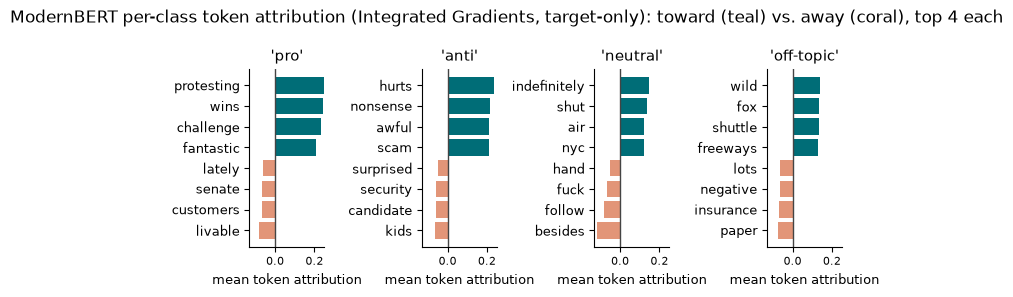

saved -> outputs/mbert_tokens_1x4_target_1GPU.png


In [ ]:
TAG = "_target_1GPU"
# ── 1×4 ModernBERT token-importance small multiple: 4 toward + 4 away per class ──
# Reads the existing per-class IG attributions (outputs/mbert_tokens_*.csv). No recompute.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path.cwd()
RED, BLUE = "#c0504d", "#3b6ea5"        # toward (+) / away (−)
PER_SIDE  = 4
PANELS    = ["pro", "anti", "neutral", "off-topic"]

fig, axes = plt.subplots(1, 4, figsize=(7, 3))
for ax, cls in zip(axes, PANELS):
    d   = pd.read_csv(OUT / f"mbert_tokens_{cls}{TAG}.csv").sort_values("mean_attr", ascending=False)
    sub = pd.concat([d.head(PER_SIDE), d.tail(PER_SIDE)]).drop_duplicates("token").sort_values("mean_attr")
    y   = np.arange(len(sub))
    ax.barh(y, sub["mean_attr"], color=['#006D77' if v > 0 else '#E29578' for v in sub["mean_attr"]])
    ax.axvline(0, color="#444", lw=1)
    ax.set_xlim(-0.13, 0.25)                          # <-- consistent scale across panels
    ax.set_yticks(y); ax.set_yticklabels(sub["token"], fontsize=9)
    ax.set_title(f"'{cls}'", fontsize=11)
    ax.set_xlabel("mean token attribution", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.suptitle("ModernBERT per-class token attribution (Integrated Gradients, target-only): "
             "toward (teal) vs. away (coral), top 4 each", fontsize=12, y=.975)
fig.tight_layout()
fig.savefig(OUT / f"mbert_tokens_1x4{TAG}.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"saved -> outputs/mbert_tokens_1x4{TAG}.png")

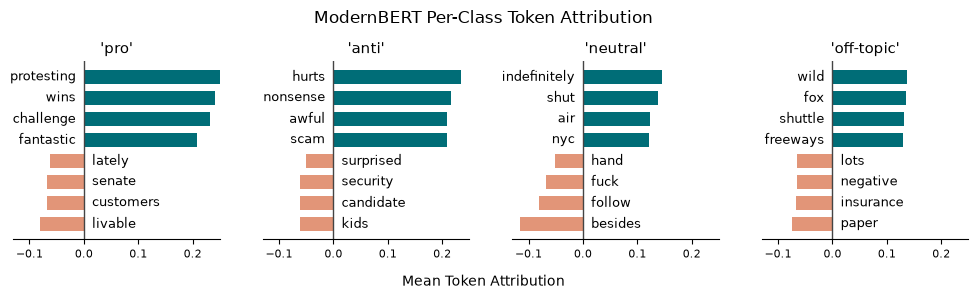

saved -> outputs/mbert_tokens_1x4_target_1GPU.png


In [ ]:
TAG = "_target_1GPU"
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path.cwd()
PER_SIDE  = 4
PANELS    = ["pro", "anti", "neutral", "off-topic"]

# 1. Reduce figure size to closely match standard document width (approx 7.5 to 8 inches)
fig, axes = plt.subplots(1, 4, figsize=(10, 3.1)) 

for ax, cls in zip(axes, PANELS):
    d   = pd.read_csv(OUT / f"mbert_tokens_{cls}{TAG}.csv").sort_values("mean_attr", ascending=False)
    sub = pd.concat([d.head(PER_SIDE), d.tail(PER_SIDE)]).drop_duplicates("token").sort_values("mean_attr")
    y   = np.arange(len(sub))
    
    # Render bars
    ax.barh(y, sub["mean_attr"], color=['#006D77' if v > 0 else '#E29578' for v in sub["mean_attr"]], height=0.7)
    ax.axvline(0, color="#444", lw=1)
    ax.set_xlim(-0.13, 0.25)
    
    # 2. Disable default y-ticks to reclaim margin space
    ax.set_yticks([]) 
    
    # 3. Dynamic label placement in the whitespace opposite the bar
    for i, (val, token) in enumerate(zip(sub["mean_attr"], sub["token"])):
        if val > 0:
            # Bar extends right; place text to the left of the zero line
            ax.text(-0.015, i, token, ha='right', va='center', fontsize=9)
        else:
            # Bar extends left; place text to the right of the zero line
            ax.text(0.015, i, token, ha='left', va='center', fontsize=9)

    ax.set_title(f"'{cls}'", fontsize=11)
    ax.tick_params(axis="x", labelsize=8)
    
    # Clean up spines (removed left spine as well, since the zero-line handles that visual boundary)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)

# 4. Consolidate redundant x-axis labels into one
fig.supxlabel("Mean Token Attribution", fontsize=10, y=0.05)

# 5. Shortened title (move the methodology details to your document's caption)
fig.suptitle("ModernBERT Per-Class Token Attribution", fontsize=12, y=.95)
# fig.suptitle("ModernBERT per-class token attribution (Integrated Gradients, target-only): "
#              "toward (teal) vs. away (coral), top 4 each", fontsize=12, y=.975)
# Reduce spacing between subplots now that y-labels aren't in the way
fig.tight_layout(w_pad=1.5) 
fig.savefig(OUT / f"mbert_tokens_1x4{TAG}.png", dpi=300, bbox_inches="tight") # Upped DPI to 300 for document clarity
plt.show()
print(f"saved -> outputs/mbert_tokens_1x4{TAG}.png")

# Target ablation, 2-GPU

In [ ]:
import subprocess, sys, threading
from pathlib import Path

HERE = Path.cwd()
PY   = sys.executable                      # the mads-m2-eval kernel's python
SHARDS = [HERE / "outputs" / "raw_target.shard0.csv",
          HERE / "outputs" / "raw_target.shard1.csv"]

def launch(gpu, shard, outp):
    cmd = [PY, str(HERE / "attribute_tokens.py"),
           "--gpu", str(gpu), "--shard", str(shard), "--n-shards", "2", "--out", str(outp)]
    return subprocess.Popen(cmd, cwd=str(HERE), stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, bufsize=1)

procs = [launch(0, 0, SHARDS[0]), launch(1, 1, SHARDS[1])]

def tail(p, t):
    for line in p.stdout:
        print(f"[{t}] {line.rstrip()}", flush=True)

ts = [threading.Thread(target=tail, args=(p, f"g{i}")) for i, p in enumerate(procs)]
for t in ts: t.start()
for t in ts: t.join()
codes = [p.wait() for p in procs]
print("exit codes:", codes, "(both 0 = success)")

[g0] 
[g1] 
[g0] Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 138/138 [00:00<00:00, 6571.38it/s]
[g1] [gpu1 shard1] 2415 of 4830 pool items | n_steps=24 ibs=32 target_only=True
[g0] [gpu0 shard0] 2415 of 4830 pool items | n_steps=24 ibs=32 target_only=True
[g1] [gpu1 shard1] 50/2415 (2%) elapsed 0.1m eta 5.5m
[g0] [gpu0 shard0] 50/2415 (2%) elapsed 0.1m eta 4.9m
[g1] [gpu1 shard1] 100/2415 (4%) elapsed 0.2m eta 5.1m
[g0] [gpu0 shard0] 100/2415 (4%) elapsed 0.2m eta 4.9m
[g1] [gpu1 shard1] 150/2415 (6%) elapsed 0.3m eta 4.7m
[g0] [gpu0 shard0] 150/2415 (6%) elapsed 0.3m eta 4.7m
[g1] [gpu1 shard1] 200/2415 (8%) elapsed 0.4m eta 4.6m
[g0] [gpu0 shard0] 200/2415 (8%) elapsed 0.4m eta 4.6m
[g1] [gpu1 shard1] 250/2415 (10%) elapsed 0.5m eta 4.4m
[g1] [gpu1 shard1] 300/2415 (12%) elapsed 0.6m eta 4.3m
[g0] [gpu0 shard0] 250/2415 (10%) elapsed 0.5m eta 4.6m
[g1] [gpu1 shard1] 350/2415 (14%) elapsed 0.7m eta 4.2m
[g0] [gpu0 shard0] 300/2415 (12%) elapsed 0.6m eta 4.5m
[g1] [gpu1 shard

In [ ]:
import pandas as pd
TAG    = "_target"
OUTDIR = HERE / "outputs"          # absolute — avoids the relative-path WinError

parts  = [pd.read_csv(s) for s in SHARDS]
merged = (pd.concat(parts, ignore_index=True)
            .groupby(["class", "token"], as_index=False)
            .agg(attr_sum=("attr_sum", "sum"), n=("n", "sum")))
merged["mean_attr"] = merged["attr_sum"] / merged["n"]
merged[["class", "token", "mean_attr", "n"]].to_csv(OUTDIR / f"mbert_word_attr_raw{TAG}.csv", index=False)

def write_token_csvs(raw, min_df=5, top_k=20, tag=TAG):
    for c in raw["class"].unique():
        d = raw[(raw["class"] == c) & (raw["n"] >= min_df)].sort_values("mean_attr", ascending=False)
        top = pd.concat([d.head(top_k), d.tail(top_k)]).drop_duplicates("token")
        top[["token", "mean_attr", "n"]].to_csv(OUTDIR / f"mbert_tokens_{c}{tag}.csv", index=False)

write_token_csvs(merged, min_df=5, top_k=20)
print("merged:", merged.shape, "-> wrote to", OUTDIR)

merged: (27819, 5) -> wrote to outputs


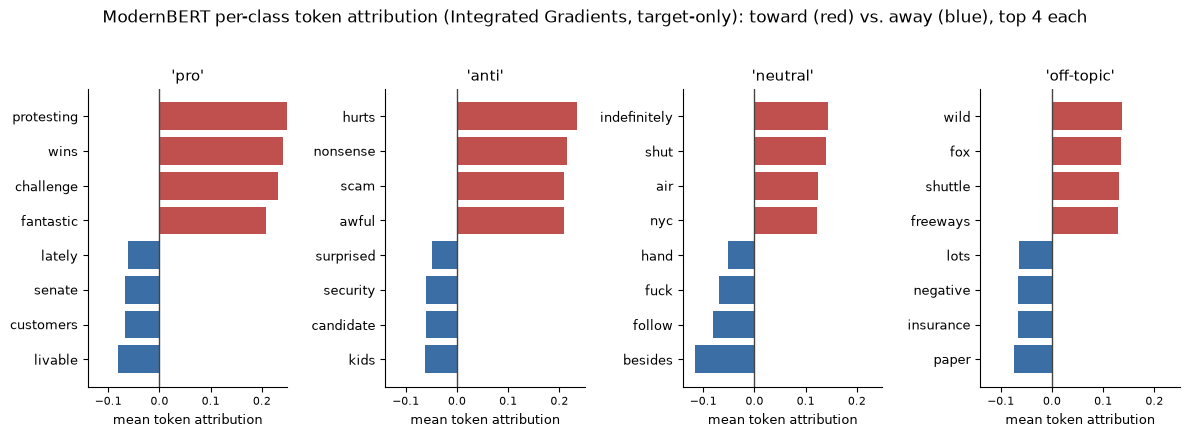

saved -> outputs\mbert_tokens_1x4_target.png


In [ ]:
# ── 1×4 ModernBERT token-importance small multiple: 4 toward + 4 away per class ──
# Reads the existing per-class IG attributions (outputs/mbert_tokens_*.csv). No recompute.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()
OUT  = HERE / "outputs"                       # absolute — avoids the relative-path WinError
TAG  = "_target"
RED, BLUE = "#c0504d", "#3b6ea5"              # toward (+) / away (−)
PER_SIDE  = 4                                 # 4 toward + 4 away = 8 tokens per class
PANELS    = ["pro", "anti", "neutral", "off-topic"]   # report order

fig, axes = plt.subplots(1, 4, figsize=(12, 4.2))
for ax, cls in zip(axes, PANELS):
    d   = pd.read_csv(OUT / f"mbert_tokens_{cls}{TAG}.csv").sort_values("mean_attr", ascending=False)
    sub = pd.concat([d.head(PER_SIDE), d.tail(PER_SIDE)]).drop_duplicates("token").sort_values("mean_attr")
    y   = np.arange(len(sub))
    ax.barh(y, sub["mean_attr"], color=[RED if v > 0 else BLUE for v in sub["mean_attr"]])
    ax.axvline(0, color="#444", lw=1)
    ax.set_xlim(-0.14, 0.25)                  # consistent scale across panels
    ax.set_yticks(y); ax.set_yticklabels(sub["token"], fontsize=9)
    ax.set_title(f"'{cls}'", fontsize=11)
    ax.set_xlabel("mean token attribution", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.suptitle("ModernBERT per-class token attribution (Integrated Gradients, target-only): "
             "toward (red) vs. away (blue), top 4 each", fontsize=12, y=1.03)
fig.tight_layout()
fig.savefig(OUT / f"mbert_tokens_1x4{TAG}.png", dpi=160, bbox_inches="tight")
plt.show()
print("saved ->", OUT / f"mbert_tokens_1x4{TAG}.png")